# Training Script for ML Time Series Models


## Settings and Imports


In [1]:
#!/usr/bin/env python3
import os
import joblib

from utils.data_preparation import prepare_data_for_modeling
from utils.visualize_model_performance import evaluate_and_plot_model_sklearn

retrain = True

os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)

# This features describe the today's weather and load. We will predict the load of the next day
FEATURES_TODAY = ['Temp', 'Min Temp', 'Max Temp', 'Wind Speed',
                  'Sunshine Duration', 'Cloud Cover', 'load_mw', 'lag_1',
                  'lag_7', 'lag_14', 'rolling_mean_7']

# These features describe the features of the next day (e.g. is it a weekend, holiday, etc.). We will predict the load of the next day
FEATURES_TARGET_TIME = ['is_weekend', 'is_holiday',
                        'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

FEATURES = FEATURES_TODAY + FEATURES_TARGET_TIME

# We will predict the load of the next day
TARGET = "load_tomorrow"

SCALE_FEATURES = ['Temp', 'Min Temp', 'Max Temp', 'Wind Speed',
                  'Sunshine Duration', 'Cloud Cover', 'load_mw', 'lag_1',
                  'lag_7', 'lag_14', 'rolling_mean_7']

## Dataset Loading and Preparation


In [2]:
data_dict, _ = prepare_data_for_modeling(FEATURES, TARGET, SCALE_FEATURES, save_scaler=True, save_data=True)
# Training Data
X_train_scaled = data_dict['X_train_scaled']
X_train = data_dict['X_train']
y_train = data_dict['y_train']

# Validation Data
X_val_scaled = data_dict['X_val_scaled']
X_val = data_dict['X_val']
y_val = data_dict['y_val']

# Test Data
X_test_scaled = data_dict['X_test_scaled']
X_test = data_dict['X_test']
y_test = data_dict['y_test']
test_df = data_dict['test_df'] # For the timestamps

## Training


### 1.) Random Forest Regressor


Test MAE: 1139.96
Test RMSE: 1640.75


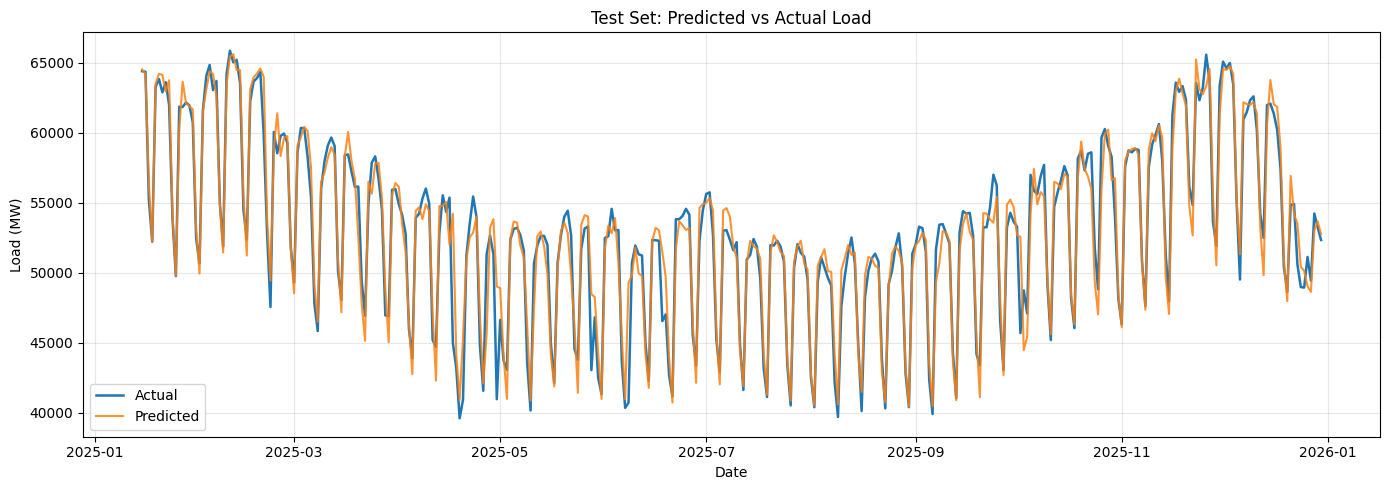

In [3]:
if not os.path.exists("models/rf_load_forecaster.joblib") or retrain:
    from sklearn.ensemble import RandomForestRegressor

    rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_regressor.fit(X_train_scaled, y_train)

    # evaluate_and_plot_model(rf_regressor, X_val_scaled, y_val, val_df)
    evaluate_and_plot_model_sklearn(rf_regressor, X_test_scaled, y_test, test_df)

    joblib.dump(rf_regressor, "models/rf_load_forecaster.joblib")

### 2.) XGBoost Regressor


Test MAE: 1164.98
Test RMSE: 1665.33


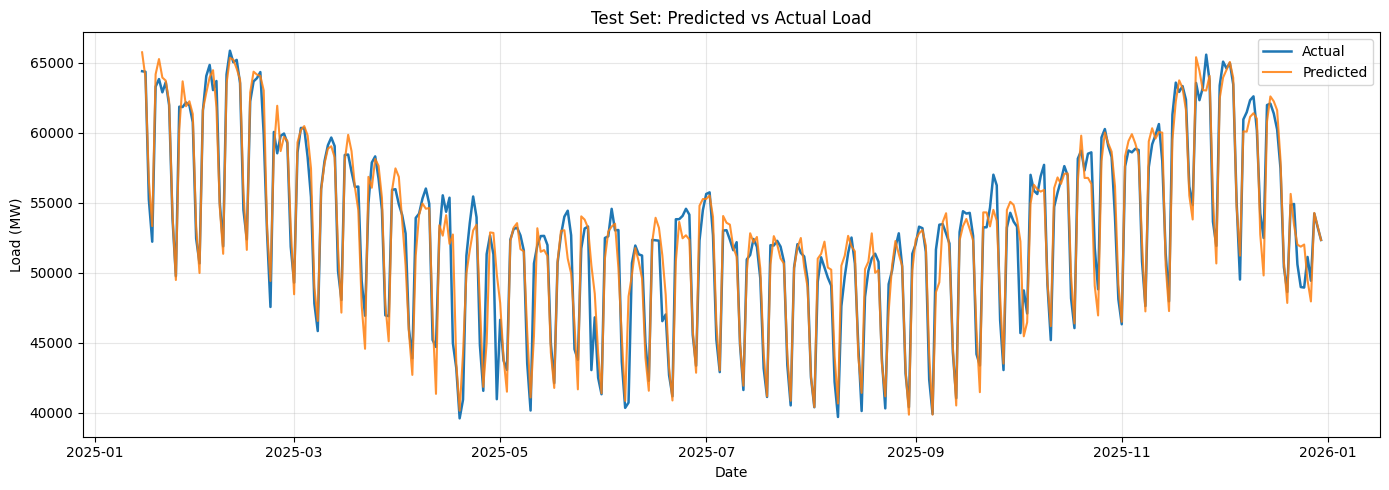

In [4]:
if not os.path.exists("models/xgb_load_forecaster.joblib") or retrain:
    from xgboost import XGBRegressor

    xgb_regressor = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )
    xgb_regressor.fit(X_train_scaled, y_train)

    # evaluate_and_plot_model(xgb_regressor, X_val_scaled, y_val, val_df)
    evaluate_and_plot_model_sklearn(xgb_regressor, X_test_scaled, y_test, test_df)

    joblib.dump(xgb_regressor, "models/xgb_load_forecaster.joblib")